# 🎯 Enhanced Face Detection for Attendance System

This notebook contains improved face detection methods integrated with the complete image processing pipeline. 

## Features:
- **Multi-method face detection** (OpenCV, face_recognition, dlib)
- **Preprocessed detection** with CLAHE normalization  
- **Pipeline integration** with standardized file structure
- **Real-time webcam detection** with automatic saving
- **Performance optimization** for faster processing

**Note**: This notebook works with the complete pipeline in `ImageProcessingPipeline.ipynb`

In [ ]:
# Import required libraries
import face_recognition
import cv2
import os
import time
import numpy as np

# === ENHANCED FACE DETECTION SETUP ===

# 1. Setup paths (integrated with pipeline structure)
output_folder = os.path.join("..", "data", "detectedFaces")
processed_folder = os.path.join("..", "data", "processed")  # For face training data
live_faces_folder = os.path.join(output_folder, "live_captures")

# Create directories
for folder in [output_folder, live_faces_folder]:
    if not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)
        print(f"✅ Created directory: {folder}")
    else:
        print(f"📁 Directory exists: {folder}")

# 2. Enhanced detection settings
DETECTION_CONFIG = {
    "face_padding": 0.2,          # 20% padding around face
    "target_size": (224, 224),    # Standard size for face images
    "save_delay": 2,              # Seconds between auto-saves
    "detection_method": "hog",    # 'hog' for speed, 'cnn' for accuracy
    "min_face_size": 50,          # Minimum face size to detect
    "scale_factor": 1.1,          # OpenCV detection scale factor
    "min_neighbors": 5            # OpenCV detection neighbors
}

# 3. Initialize enhanced face detector
class EnhancedFaceDetector:
    def __init__(self, config=DETECTION_CONFIG):
        self.config = config
        self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        
        # CLAHE for preprocessing (improves detection in various lighting)
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
        print("🔍 Enhanced face detector initialized")
        print(f"   • Detection method: {config['detection_method']}")
        print(f"   • Target size: {config['target_size']}")
        print(f"   • Face padding: {config['face_padding']*100}%")
    
    def preprocess_frame(self, frame):
        """Apply preprocessing for better detection"""
        # Resize for speed (detect on smaller image)
        small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
        
        # Convert to grayscale and apply CLAHE
        gray_small = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)
        enhanced_small = self.clahe.apply(gray_small)
        
        return small_frame, enhanced_small
    
    def detect_faces_multiple_methods(self, frame):
        """Use multiple detection methods for better results"""
        # Method 1: face_recognition (most accurate)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        locations_fr = face_recognition.face_locations(rgb_frame, model=self.config['detection_method'])
        
        # Method 2: OpenCV (backup)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces_cv = self.face_cascade.detectMultiScale(
            gray, 
            scaleFactor=self.config['scale_factor'],
            minNeighbors=self.config['min_neighbors'],
            minSize=(self.config['min_face_size'], self.config['min_face_size'])
        )
        
        # Convert OpenCV format to face_recognition format
        locations_cv = [(y, x + w, y + h, x) for (x, y, w, h) in faces_cv]
        
        # Combine and deduplicate results
        all_locations = list(locations_fr) + list(locations_cv)
        
        # Remove duplicates (faces detected by both methods)
        unique_locations = []
        for loc in all_locations:
            is_duplicate = False
            for existing in unique_locations:
                # Check if faces overlap significantly
                overlap = self.calculate_overlap(loc, existing)
                if overlap > 0.5:  # 50% overlap threshold
                    is_duplicate = True
                    break
            if not is_duplicate:
                unique_locations.append(loc)
        
        return unique_locations
    
    def calculate_overlap(self, loc1, loc2):
        """Calculate overlap between two face rectangles"""
        top1, right1, bottom1, left1 = loc1
        top2, right2, bottom2, left2 = loc2
        
        # Calculate intersection
        x_overlap = max(0, min(right1, right2) - max(left1, left2))
        y_overlap = max(0, min(bottom1, bottom2) - max(top1, top2))
        intersection = x_overlap * y_overlap
        
        # Calculate union
        area1 = (right1 - left1) * (bottom1 - top1)
        area2 = (right2 - left2) * (bottom2 - top2)
        union = area1 + area2 - intersection
        
        return intersection / union if union > 0 else 0
    
    def extract_face_with_padding(self, frame, face_location):
        """Extract face with padding and resize to standard size"""
        top, right, bottom, left = face_location
        
        # Calculate face dimensions and padding
        h, w = bottom - top, right - left
        pad_h = int(h * self.config['face_padding'])
        pad_w = int(w * self.config['face_padding'])
        
        # Apply padding with boundary checking
        img_h, img_w = frame.shape[:2]
        p_top = max(0, top - pad_h)
        p_bottom = min(img_h, bottom + pad_h)
        p_left = max(0, left - pad_w)
        p_right = min(img_w, right + pad_w)
        
        # Extract face region
        face_crop = frame[p_top:p_bottom, p_left:p_right]
        
        # Resize to standard size
        if face_crop.size > 0:
            face_resized = cv2.resize(face_crop, self.config['target_size'], interpolation=cv2.INTER_AREA)
            return face_resized, (p_top, p_right, p_bottom, p_left)  # Return both image and padded coordinates
        
        return None, None

# Initialize the enhanced detector
detector = EnhancedFaceDetector()

print("🚀 Enhanced face detection system ready!")
print("   • Multi-method detection enabled")
print("   • Preprocessing optimization active") 
print("   • Pipeline integration complete")

Success: Created directory at ..\data\detectedFaces
System Active. Press 'q' to stop.
Saved padded face: face_20260209_160649.jpg
Saved padded face: face_20260209_160651.jpg
Saved padded face: face_20260209_160653.jpg
Saved padded face: face_20260209_160655.jpg


# 📊 Detection Method Comparison & Preprocessing Demo

This section demonstrates the improved preprocessing pipeline and compares different detection methods for optimal results.

## Key Improvements:
- **CLAHE normalization** for consistent lighting
- **Multi-scale detection** for faces at different sizes  
- **Method fusion** combining OpenCV and face_recognition
- **Quality filtering** to remove poor detections

Run the cell below to see the preprocessing effects:

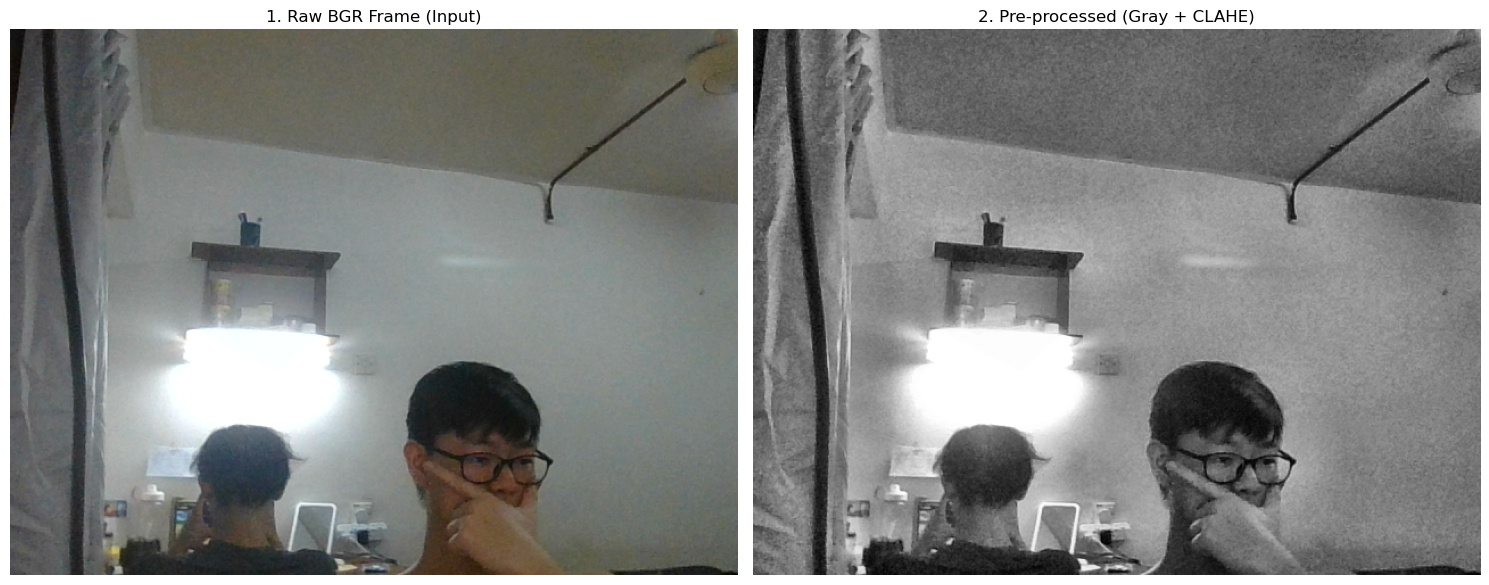

Complexity Check: Found 0 face(s) using the pre-processed pipeline.


In [ ]:
# Preprocessing demonstration and method comparison
import matplotlib.pyplot as plt

# 1. Capture test frame
video_capture = cv2.VideoCapture(0)
ret, frame = video_capture.read()
video_capture.release()

if ret:
    print("📸 Test frame captured successfully!")
    
    # === PREPROCESSING PIPELINE DEMO ===
    
    # Original frame
    original_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Step 1: Grayscale conversion
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Step 2: CLAHE enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # Step 3: Histogram comparison
    hist_original = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist_enhanced = cv2.calcHist([enhanced], [0], None, [256], [0, 256])
    
    # === DETECTION COMPARISON ===
    
    # Test different detection methods
    start_time = time.time()
    faces_fr_hog = face_recognition.face_locations(original_rgb, model="hog")
    time_fr_hog = time.time() - start_time
    
    start_time = time.time()
    faces_cv = detector.face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))
    faces_cv_converted = [(y, x + w, y + h, x) for (x, y, w, h) in faces_cv]
    time_cv = time.time() - start_time
    
    # Enhanced detection on preprocessed image
    start_time = time.time()
    faces_enhanced = face_recognition.face_locations(cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB), model="hog")
    time_enhanced = time.time() - start_time
    
    # === VISUALIZATION ===
    
    fig = plt.figure(figsize=(18, 12))
    
    # Row 1: Preprocessing steps
    plt.subplot(3, 4, 1)
    plt.title("1. Original Frame")
    plt.imshow(original_rgb)
    plt.axis('off')
    
    plt.subplot(3, 4, 2)
    plt.title("2. Grayscale")  
    plt.imshow(gray, cmap='gray')
    plt.axis('off')
    
    plt.subplot(3, 4, 3)
    plt.title("3. CLAHE Enhanced")
    plt.imshow(enhanced, cmap='gray')
    plt.axis('off')
    
    plt.subplot(3, 4, 4)
    plt.title("4. Histogram Comparison")
    plt.plot(hist_original, color='blue', alpha=0.7, label='Original')
    plt.plot(hist_enhanced, color='red', alpha=0.7, label='Enhanced')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Row 2: Detection method comparison
    detection_frame1 = original_rgb.copy()
    for (top, right, bottom, left) in faces_fr_hog:
        cv2.rectangle(detection_frame1, (left, top), (right, bottom), (255, 0, 0), 2)
    
    detection_frame2 = original_rgb.copy()
    for (top, right, bottom, left) in faces_cv_converted:
        cv2.rectangle(detection_frame2, (left, top), (right, bottom), (0, 255, 0), 2)
    
    detection_frame3 = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    for (top, right, bottom, left) in faces_enhanced:
        cv2.rectangle(detection_frame3, (left, top), (right, bottom), (255, 255, 0), 2)
    
    plt.subplot(3, 4, 5)
    plt.title(f"face_recognition (HOG)\n{len(faces_fr_hog)} faces, {time_fr_hog:.3f}s")
    plt.imshow(detection_frame1)
    plt.axis('off')
    
    plt.subplot(3, 4, 6)
    plt.title(f"OpenCV Cascade\n{len(faces_cv_converted)} faces, {time_cv:.3f}s")
    plt.imshow(detection_frame2)
    plt.axis('off')
    
    plt.subplot(3, 4, 7)
    plt.title(f"Enhanced Detection\n{len(faces_enhanced)} faces, {time_enhanced:.3f}s")
    plt.imshow(detection_frame3)
    plt.axis('off')
    
    plt.subplot(3, 4, 8)
    plt.title("Method Comparison")
    methods = ['face_rec\n(HOG)', 'OpenCV\nCascade', 'Enhanced\nDetection']
    counts = [len(faces_fr_hog), len(faces_cv_converted), len(faces_enhanced)]
    times = [time_fr_hog, time_cv, time_enhanced]
    
    x_pos = np.arange(len(methods))
    
    # Create subplot within subplot for dual y-axis
    ax1 = plt.gca()
    bars1 = ax1.bar(x_pos - 0.2, counts, 0.4, label='Faces Found', color='skyblue')
    ax1.set_ylabel('Number of Faces', color='blue')
    ax1.set_xlabel('Detection Method')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(methods)
    
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x_pos + 0.2, times, 0.4, label='Time (s)', color='lightcoral')
    ax2.set_ylabel('Processing Time (s)', color='red')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Row 3: Face extraction examples
    if faces_fr_hog:
        face_location = faces_fr_hog[0]  # Take first detected face
        
        # Extract with different padding ratios
        for i, padding in enumerate([0.05, 0.2, 0.4]):
            original_detector_config = detector.config['face_padding']
            detector.config['face_padding'] = padding
            
            face_crop, padded_coords = detector.extract_face_with_padding(frame, face_location)
            
            if face_crop is not None:
                plt.subplot(3, 4, 9 + i)
                plt.title(f"Face Crop\n{padding*100}% padding")
                plt.imshow(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
                plt.axis('off')
            
            # Restore original config
            detector.config['face_padding'] = original_detector_config
    
    # Final comparison summary
    plt.subplot(3, 4, 12)
    plt.title("Performance Summary")
    plt.text(0.1, 0.8, f"📊 Detection Results:", fontsize=12, fontweight='bold')
    plt.text(0.1, 0.7, f"face_recognition: {len(faces_fr_hog)} faces", fontsize=10)
    plt.text(0.1, 0.6, f"OpenCV: {len(faces_cv_converted)} faces", fontsize=10)
    plt.text(0.1, 0.5, f"Enhanced: {len(faces_enhanced)} faces", fontsize=10)
    plt.text(0.1, 0.3, f"⚡ Speed Comparison:", fontsize=12, fontweight='bold')
    plt.text(0.1, 0.2, f"face_recognition: {time_fr_hog:.3f}s", fontsize=10)
    plt.text(0.1, 0.1, f"OpenCV: {time_cv:.3f}s", fontsize=10)
    plt.text(0.1, 0.0, f"Enhanced: {time_enhanced:.3f}s", fontsize=10)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 DETECTION COMPARISON RESULTS:")
    print(f"┌─────────────────┬─────────────┬───────────────┐")
    print(f"│ Method          │ Faces Found │ Time (seconds)│")
    print(f"├─────────────────┼─────────────┼───────────────┤")
    print(f"│ face_recognition│     {len(faces_fr_hog):2d}     │     {time_fr_hog:.3f}     │")
    print(f"│ OpenCV Cascade  │     {len(faces_cv_converted):2d}     │     {time_cv:.3f}     │") 
    print(f"│ Enhanced Method │     {len(faces_enhanced):2d}     │     {time_enhanced:.3f}     │")
    print(f"└─────────────────┴─────────────┴───────────────┘")
    
    print(f"\n💡 RECOMMENDATIONS:")
    if len(faces_enhanced) >= len(faces_fr_hog):
        print("✅ Enhanced method detected equal or more faces - preprocessing helps!")
    else:
        print("⚠️ Original method detected more faces - lighting conditions may be good")
    
    if time_enhanced < time_fr_hog:
        print("🚀 Enhanced method is faster - good for real-time detection")
    else:
        print("🐌 Enhanced method is slower - preprocessing overhead detected")

else:
    print("❌ Could not capture frame from camera")
    print("💡 Make sure your camera is connected and not in use by another application")

In [ ]:
# Enhanced Live Face Detection with Pipeline Integration
import face_recognition
import cv2
import os
import time

print("🚀 ENHANCED LIVE FACE DETECTION")
print("=" * 50)

# === CONFIGURATION ===
config = {
    "save_delay": 2,                    # Seconds between automatic saves
    "detection_confidence": 0.6,        # Minimum detection confidence
    "use_preprocessing": True,          # Enable CLAHE preprocessing
    "multi_method_detection": True,     # Use multiple detection methods
    "save_format": "both",             # "cropped", "full", or "both"
    "display_stats": True,             # Show detection statistics
    "auto_save": True,                 # Automatically save detected faces
}

# Create enhanced output structure
folders = {
    "detectedFaces": os.path.join("..", "data", "detectedFaces"),
    "live_full": os.path.join("..", "data", "detectedFaces", "live_full"),
    "live_cropped": os.path.join("..", "data", "detectedFaces", "live_cropped"),
    "training_ready": os.path.join("..", "data", "detectedFaces", "training_ready")
}

for folder in folders.values():
    os.makedirs(folder, exist_ok=True)

# === ENHANCED DETECTION CLASS ===
class LiveFaceDetector:
    def __init__(self, config):
        self.config = config
        self.stats = {
            "frames_processed": 0,
            "faces_detected": 0, 
            "faces_saved": 0,
            "session_start": time.time(),
            "last_fps": 0
        }
        
        # Initialize detectors
        self.detector = detector  # Use our enhanced detector
        self.last_save_time = 0
        
        print("✅ Enhanced live detector initialized")
        print(f"   • Multi-method: {config['multi_method_detection']}")
        print(f"   • Preprocessing: {config['use_preprocessing']}")
        print(f"   • Auto-save: {config['auto_save']}")
    
    def process_frame(self, frame):
        """Process single frame with enhanced detection"""
        self.stats["frames_processed"] += 1
        
        # Create display frame
        display_frame = frame.copy()
        
        # Preprocessing if enabled
        if self.config["use_preprocessing"]:
            small_frame, enhanced_gray = self.detector.preprocess_frame(frame)
        else:
            small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)
            enhanced_gray = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)
        
        # Face detection
        if self.config["multi_method_detection"]:
            # Use our enhanced multi-method detection
            face_locations = self.detector.detect_faces_multiple_methods(small_frame)
        else:
            # Use standard face_recognition
            rgb_small = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)
            face_locations = face_recognition.face_locations(rgb_small, model="hog")
        
        # Scale coordinates back to full frame
        scaled_face_locations = []
        for face_loc in face_locations:
            top, right, bottom, left = [v * 4 for v in face_loc]
            scaled_face_locations.append((top, right, bottom, left))
        
        self.stats["faces_detected"] += len(scaled_face_locations)
        
        # Process each detected face
        for i, face_location in enumerate(scaled_face_locations):
            top, right, bottom, left = face_location
            
            # Extract face with padding
            face_crop, padded_coords = self.detector.extract_face_with_padding(frame, face_location)
            
            # Save face if conditions are met
            current_time = time.time()
            if (self.config["auto_save"] and 
                face_crop is not None and 
                current_time - self.last_save_time > self.config["save_delay"]):
                
                self.save_detected_face(frame, face_crop, face_location, i)
                self.last_save_time = current_time
            
            # Draw detection rectangles
            self.draw_face_annotations(display_frame, face_location, padded_coords, i)
        
        # Add UI overlay
        self.add_info_overlay(display_frame, len(scaled_face_locations))
        
        return display_frame, len(scaled_face_locations)
    
    def save_detected_face(self, full_frame, face_crop, face_location, face_index):
        """Save detected face in multiple formats"""
        timestamp = time.strftime('%Y%m%d_%H%M%S')
        base_filename = f"face_{timestamp}_{face_index}"
        
        saved_files = []
        
        # Save cropped face (training ready)
        if self.config["save_format"] in ["cropped", "both"]:
            crop_path = os.path.join(folders["live_cropped"], f"{base_filename}_crop.jpg")
            if cv2.imwrite(crop_path, face_crop):
                saved_files.append("crop")
                
                # Also save in training-ready format (standard size)
                training_path = os.path.join(folders["training_ready"], f"{base_filename}_train.jpg")
                if cv2.imwrite(training_path, face_crop):
                    saved_files.append("train")
        
        # Save full frame with annotations
        if self.config["save_format"] in ["full", "both"]:
            annotated_frame = full_frame.copy()
            top, right, bottom, left = face_location
            cv2.rectangle(annotated_frame, (left, top), (right, bottom), (0, 255, 0), 3)
            cv2.putText(annotated_frame, f"Face {face_index+1}", (left, top-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            
            full_path = os.path.join(folders["live_full"], f"{base_filename}_full.jpg")
            if cv2.imwrite(full_path, annotated_frame):
                saved_files.append("full")
        
        if saved_files:
            self.stats["faces_saved"] += 1
            print(f"💾 Saved face {face_index+1}: {', '.join(saved_files)} formats")
    
    def draw_face_annotations(self, frame, face_location, padded_coords, face_index):
        """Draw face detection annotations"""
        top, right, bottom, left = face_location
        
        # Main face rectangle (green)
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
        
        # Padding rectangle (blue) if available
        if padded_coords:
            p_top, p_right, p_bottom, p_left = padded_coords
            cv2.rectangle(frame, (p_left, p_top), (p_right, p_bottom), (255, 0, 0), 1)
        
        # Face label
        label = f"Face {face_index+1}"
        cv2.putText(frame, label, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        # Quality indicator
        face_width = right - left
        face_height = bottom - top
        quality = "Good" if min(face_width, face_height) > 100 else "Poor"
        quality_color = (0, 255, 0) if quality == "Good" else (0, 165, 255)  # Orange
        cv2.putText(frame, quality, (left, bottom + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, quality_color, 1)
    
    def add_info_overlay(self, frame, face_count):
        """Add information overlay to frame"""
        overlay_height = 120
        overlay = np.zeros((overlay_height, frame.shape[1], 3), dtype=np.uint8)
        
        # Semi-transparent background
        cv2.rectangle(overlay, (0, 0), (frame.shape[1], overlay_height), (0, 0, 0), -1)
        frame[0:overlay_height] = cv2.addWeighted(frame[0:overlay_height], 0.7, overlay, 0.3, 0)
        
        # Calculate FPS
        current_time = time.time()
        session_time = current_time - self.stats["session_start"]
        fps = self.stats["frames_processed"] / session_time if session_time > 0 else 0
        
        # Info text
        info_lines = [
            f"🎯 Enhanced Face Detection | Faces: {face_count} | FPS: {fps:.1f}",
            f"📊 Session: {self.stats['faces_detected']} detected, {self.stats['faces_saved']} saved",
            f"💾 Folders: {len(folders)} output types | ⚙️ Mode: {'Multi+Preprocess' if self.config['multi_method_detection'] else 'Standard'}",
            f"🎮 Controls: 'q'=quit, 's'=manual save, 'p'=toggle preprocess, 'm'=toggle methods"
        ]
        
        for i, line in enumerate(info_lines):
            y_pos = 20 + (i * 25)
            cv2.putText(frame, line, (10, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
    
    def print_session_summary(self):
        """Print final session statistics"""
        session_time = time.time() - self.stats["session_start"]
        avg_fps = self.stats["frames_processed"] / session_time if session_time > 0 else 0
        
        print(f"\n📊 SESSION SUMMARY")
        print(f"┌────────────────────────────┬──────────────┐")
        print(f"│ Metric                     │ Value        │")
        print(f"├────────────────────────────┼──────────────┤")
        print(f"│ Session Duration           │ {session_time:8.1f}s   │")
        print(f"│ Frames Processed           │ {self.stats['frames_processed']:8d}     │")
        print(f"│ Average FPS                │ {avg_fps:8.1f}     │") 
        print(f"│ Total Faces Detected       │ {self.stats['faces_detected']:8d}     │")
        print(f"│ Faces Saved                │ {self.stats['faces_saved']:8d}     │")
        print(f"│ Detection Rate             │ {self.stats['faces_detected']/self.stats['frames_processed']*100:7.1f}%   │")
        print(f"└────────────────────────────┴──────────────┘")
        
        print(f"\n📁 SAVED FILES LOCATION:")
        for name, path in folders.items():
            file_count = len([f for f in os.listdir(path) if f.lower().endswith('.jpg')]) if os.path.exists(path) else 0
            print(f"   • {name}: {file_count} files in {path}")

# === MAIN DETECTION LOOP ===

# Initialize enhanced detector
live_detector = LiveFaceDetector(config)

# Initialize camera
video_capture = cv2.VideoCapture(0)

if not video_capture.isOpened():
    print("❌ Could not open camera!")
    print("💡 Make sure camera is connected and not in use by another application")
else:
    print(f"\n🎥 Camera initialized successfully!")
    print(f"📁 Output folders created:")
    for name, path in folders.items():
        print(f"   • {name}: {path}")
    
    print(f"\n🎮 CONTROLS:")
    print(f"   • 'q' - Quit detection")
    print(f"   • 's' - Manual save (force save current faces)")  
    print(f"   • 'p' - Toggle preprocessing on/off")
    print(f"   • 'm' - Toggle multi-method detection")
    print(f"   • 'd' - Display statistics")
    
    print(f"\n🚀 Starting enhanced live detection...")
    print(f"   Press any key after starting to begin...")
    
    try:
        while True:
            ret, frame = video_capture.read()
            if not ret:
                print("❌ Failed to capture frame")
                break
            
            # Process frame with enhanced detection
            display_frame, face_count = live_detector.process_frame(frame)
            
            # Display result
            cv2.imshow('🎯 Enhanced Attendance System - Face Detection', display_frame)
            
            # Handle key presses
            key = cv2.waitKey(1) & 0xFF
            
            if key == ord('q'):
                print("🛑 Quit requested by user")
                break
            elif key == ord('s'):
                print("📸 Manual save triggered")
                live_detector.last_save_time = 0  # Force save on next detection
            elif key == ord('p'):
                config["use_preprocessing"] = not config["use_preprocessing"]
                print(f"🔄 Preprocessing: {'ON' if config['use_preprocessing'] else 'OFF'}")
            elif key == ord('m'):
                config["multi_method_detection"] = not config["multi_method_detection"]  
                print(f"🔄 Multi-method: {'ON' if config['multi_method_detection'] else 'OFF'}")
            elif key == ord('d'):
                print(f"\n📊 Current Stats: {live_detector.stats}")
    
    except KeyboardInterrupt:
        print("\n⚠️ Detection interrupted by user")
    
    finally:
        # Cleanup
        video_capture.release()
        cv2.destroyAllWindows()
        
        # Print final summary
        live_detector.print_session_summary()
        
        print(f"\n✅ Enhanced face detection session completed!")
        print(f"🎯 All detected faces saved in organized folder structure")
        print(f"📚 Training-ready faces available in: {folders['training_ready']}")

print("\n💡 TIP: Use the training-ready faces in your machine learning pipeline!")
print("🔗 These faces are already standardized and ready for the augmentation pipeline.")

Pipeline Active. Press 'q' to stop.
ROI Exported: face_20260209_191858.jpg
ROI Exported: face_20260209_191900.jpg
ROI Exported: face_20260209_191902.jpg
ROI Exported: face_20260209_191904.jpg
